# 🔬 Cell Tracking During Development — a visual walkthrough

Tracing **every cell as a zebrafish embryo builds itself**: detect nuclei in a 3D volume, link them across
time, and catch the divisions — reconstructing each cell's *lineage*.

This notebook breaks the problem down **visually**, straight from the real data, and shows where our pipeline
stands. Every figure below is regenerated from one training clip and our own code — nothing is pre-baked.

> **Palette** (grounded in the real fluorophores): dense <span style="color:#4BE39A">**green** nuclei</span>
> (H2B-mNeonGreen), the sparse <span style="color:#FF4D7E">**magenta** ground-truth lineage</span> tracer
> (mCherry), our <span style="color:#57E0FF">**cyan** detections</span>, and <span style="color:#FFC24D">**amber**
> divisions</span>.

### Setup

In [1]:
import sys; from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"pipeline").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/"eval"))
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import tracksdata as td
from pipeline.io_zarr import VolumeSeries
from pipeline.config import PipelineConfig
from pipeline.detect import detect_cells

# microscopy palette
BG="#0A0E0D"; GREEN="#4BE39A"; MAG="#FF4D7E"; CYAN="#57E0FF"; AMBER="#FFC24D"; INK="#A9C0B7"
NG = LinearSegmentedColormap.from_list("ng", ["#04100b","#0d3b24","#2f9c5f","#7ce0a3","#d6ffe8"])
plt.rcParams.update({"figure.facecolor":BG,"axes.facecolor":BG,"savefig.facecolor":BG,
    "text.color":INK,"axes.labelcolor":INK,"xtick.color":"#5c6b64","ytick.color":"#5c6b64",
    "axes.edgecolor":"#22302a","font.family":"monospace","font.size":11})

DS = "6bba_09961292"                      # a dense clip with divisions
SCALE = np.array([1.625, 0.40625, 0.40625])   # microns per voxel (z, y, x)
vs = VolumeSeries(ROOT/"data"/"train"/f"{DS}.zarr")
gt = td.graph.IndexedRXGraph.from_geff(ROOT/"data"/"train"/f"{DS}.geff")
gt = gt[0] if isinstance(gt, tuple) else gt
T,Z,Y,X = vs.shape
print(f"clip {DS}: {T} timepoints, volume ({Z},{Y},{X}) voxels  ·  GT: {gt.num_nodes()} nodes, {gt.num_edges()} edges")

def proj(t):
    v = vs.volume(t).astype(np.float32).max(0)      # max-intensity Z projection -> (Y,X)
    lo,hi = np.percentile(v,[50,99.7]); return np.clip((v-lo)/(hi-lo+1e-6),0,1)

clip 6bba_09961292: 100 timepoints, volume (64,256,256) voxels  ·  GT: 1950 nodes, 1871 edges


## 1 · What the microscope sees

Each clip is an **OME-Zarr** volume: a stack of 64 z-slices (256×256) captured at 100 timepoints. Below, the
volume is flattened to 2D (max projection over depth) at five moments. The texture keeps shifting — that motion
is exactly what makes linking cells across frames hard.

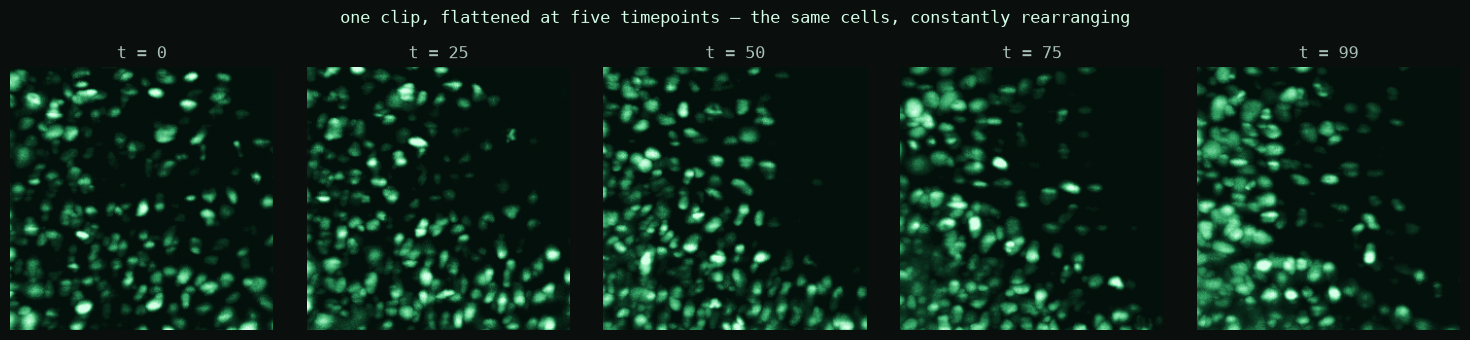

In [2]:
fig,axes = plt.subplots(1,5,figsize=(15,3.3))
for ax,t in zip(axes,[0,25,50,75,99]):
    ax.imshow(proj(t),cmap=NG,interpolation="bilinear"); ax.set_axis_off()
    ax.set_title(f"t = {t}",color=INK,fontsize=12)
fig.suptitle("one clip, flattened at five timepoints — the same cells, constantly rearranging",
             color="#d6ffe8",y=1.02,fontsize=12); plt.tight_layout(); plt.show()

## 2 · The answer is a graph — and the labels are sparse

The target is a **lineage graph**: a *node* for each cell detection `(t, z, y, x)` and an *edge* for each
parent→child link between frames. A division is one node with two outgoing edges.

But the ground truth is **sparse by design** — a second fluorophore labels only a random scattering of cells and
their descendants. Circled in magenta below are *all* the annotated cells in this frame, floating in a sea of
thousands. You never know which cells are scored, so you have to track **everything** well.

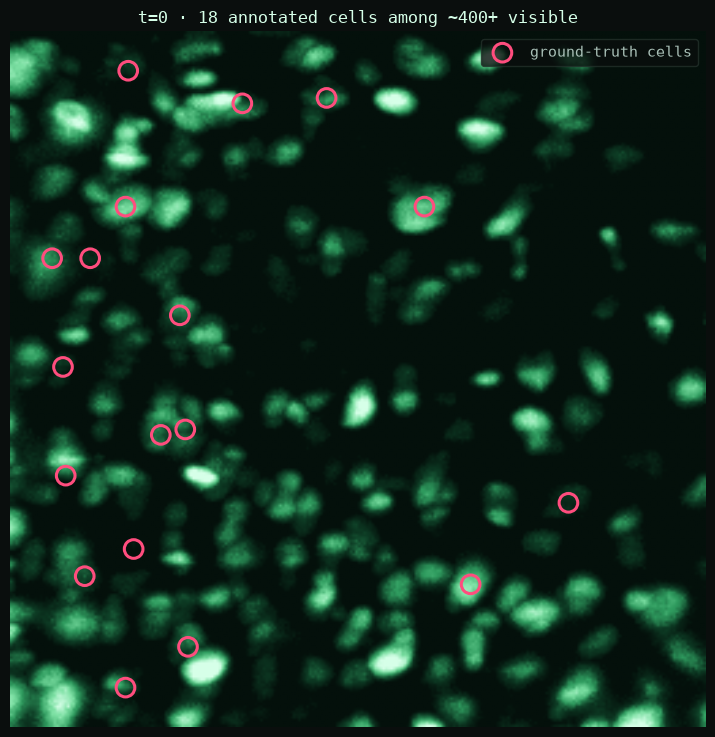

annotated cells per frame: 11–33 (median 18) · <1% of all cells


In [3]:
na = gt.node_attrs(attr_keys=["t","y","x"]); rows=list(na.iter_rows(named=True))
gt0 = [(r["x"],r["y"]) for r in rows if r["t"]==0]
fig,ax = plt.subplots(figsize=(7.5,7.5))
ax.imshow(proj(0),cmap=NG,interpolation="bilinear")
if gt0: ax.scatter(*zip(*gt0),s=180,facecolors="none",edgecolors=MAG,linewidths=2.2,label="ground-truth cells")
ax.set_axis_off(); ax.legend(loc="upper right",facecolor=BG,edgecolor="#22302a",labelcolor=INK)
ax.set_title(f"t=0 · {len(gt0)} annotated cells among ~{int(gt.num_nodes()*T/max(gt.num_edges(),1))//100*100+300}+ visible",
             color="#d6ffe8",fontsize=12); plt.tight_layout(); plt.show()
# how sparse, across all frames?
per_t = np.bincount([r["t"] for r in rows], minlength=T)
print(f"annotated cells per frame: {per_t.min()}–{per_t.max()} (median {int(np.median(per_t))}) · <1% of all cells")

## 3 · A real lineage

Here is one annotated cell followed through time. It drifts in space frame by frame, then **divides** (amber) into
two daughters that separate. Reconstructing links like these — correctly, over ~20-frame spans — is what the metric grades.

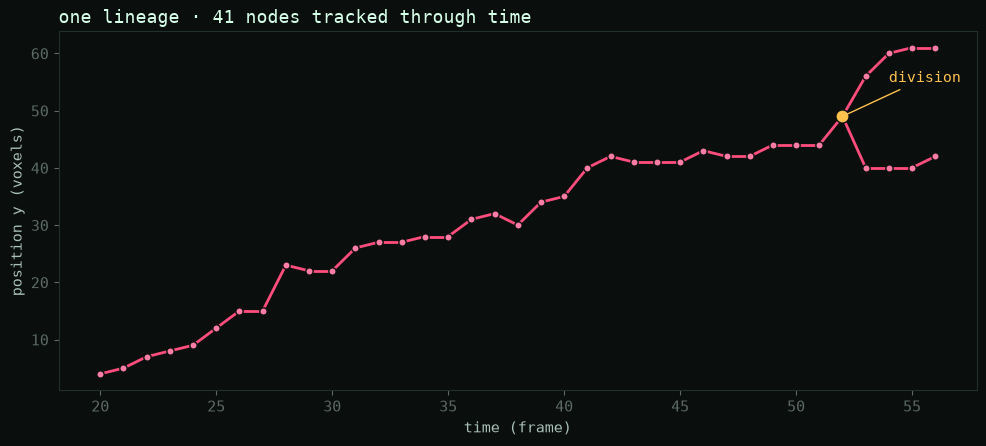

In [4]:
from collections import defaultdict, deque
pos={int(r["node_id"]):(int(r["t"]),float(r["y"])) for r in gt.node_attrs(attr_keys=["node_id","t","y"]).iter_rows(named=True)}
E=[(int(r["source_id"]),int(r["target_id"])) for r in gt.edge_attrs(attr_keys=["source_id","target_id"]).iter_rows(named=True)]
out=defaultdict(list); und=defaultdict(list)
for s,t in E: out[s].append(t); und[s].append(t); und[t].append(s)
seen=set(); comps=[]
for n in pos:
    if n in seen: continue
    c=[]; q=deque([n]); seen.add(n)
    while q:
        u=q.popleft(); c.append(u)
        for v in und[u]:
            if v not in seen: seen.add(v); q.append(v)
    comps.append(c)
comp=max([c for c in comps if any(len(out[n])>=2 for n in c)] or comps, key=len); cs=set(comp)
fig,ax=plt.subplots(figsize=(10,4.6))
for s,t in E:
    if s in cs and t in cs:
        (a,b),(c2,d)=pos[s],pos[t]; ax.plot([a,c2],[b,d],color=MAG,lw=2,solid_capstyle="round",zorder=2)
for n in comp:
    t,y=pos[n]; div=len(out[n])>=2
    ax.scatter([t],[y],s=90 if div else 28,c=AMBER if div else "#FF7DA6",edgecolors=BG,linewidths=1,zorder=3)
    if div: ax.annotate("division",(t,y),(t+2,y+6),color=AMBER,fontsize=11,
                        arrowprops=dict(arrowstyle="-",color=AMBER,lw=1))
ax.set_xlabel("time (frame)"); ax.set_ylabel("position y (voxels)")
ax.set_title(f"one lineage · {len(comp)} nodes tracked through time",color="#d6ffe8",loc="left")
plt.tight_layout(); plt.show()

## 4 · How it's scored — two rules that decide everything

Predicted cells are matched to ground truth by physical distance with a hard **7 µm tolerance**, and the score is
the Jaccard overlap of predicted vs. true *edges*. Two mechanics of that metric shaped every choice we made — and
we measured both directly with perturbation tests on the real data.

/var/folders/y6/7g1dzs8s7hx27_5qxww1bw940000gn/T/ipykernel_7974/996977126.py:15: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/var/folders/y6/7g1dzs8s7hx27_5qxww1bw940000gn/T/ipykernel_7974/996977126.py:15: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/Users/reillykoren/biohub-kaggle/.venv-track/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/reillykoren/biohub-kaggle/.venv-track/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


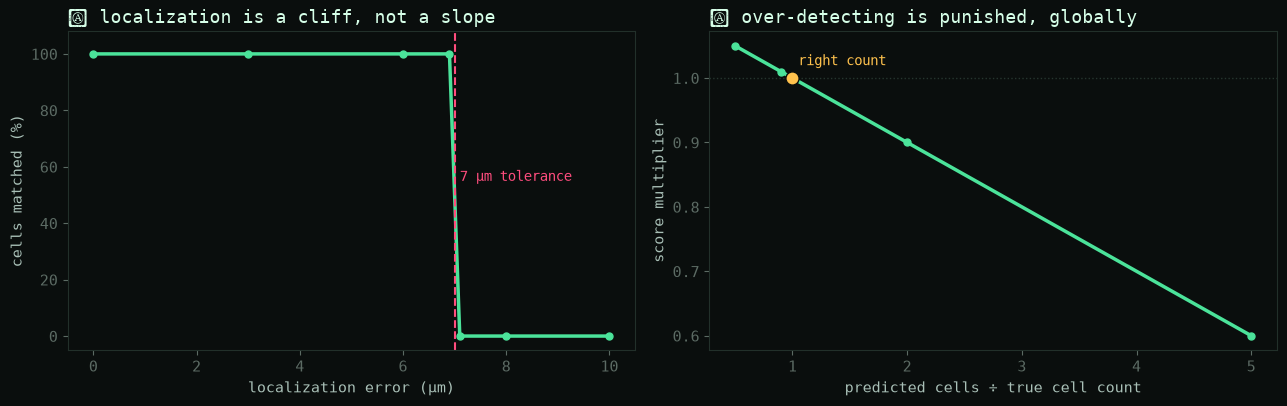

→ detections must land within 7µm (z is 4× coarser, so depth is the binding axis),
  and the total count should track the true cell count — flooding to boost recall backfires.


In [5]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.2))
# (left) localization cliff — matched% vs how far off the center is (our jitter test)
jit=[0,3,6,6.9,7.1,8,10]; matched=[100,100,100,100,0,0,0]
a1.plot(jit,matched,color=GREEN,lw=2.5,marker="o",ms=5)
a1.axvline(7,color=MAG,ls="--",lw=1.5); a1.text(7.1,55,"7 µm tolerance",color=MAG,fontsize=10)
a1.set_xlabel("localization error (µm)"); a1.set_ylabel("cells matched (%)")
a1.set_title("① localization is a cliff, not a slope",color="#d6ffe8",loc="left"); a1.set_ylim(-5,108)
# (right) node-count penalty — score multiplier vs predicted count / true count (our sweep)
ratio=[0.5,0.9,1.0,2.0,5.0]; mult=[1.05,1.01,1.00,0.90,0.60]
a2.axhline(1.0,color="#26362F",ls=":",lw=1)
a2.plot(ratio,mult,color=GREEN,lw=2.5,marker="o",ms=5)
a2.scatter([1.0],[1.0],s=90,c=AMBER,edgecolors=BG,zorder=3); a2.text(1.05,1.02,"right count",color=AMBER,fontsize=10)
a2.set_xlabel("predicted cells ÷ true cell count"); a2.set_ylabel("score multiplier")
a2.set_title("② over-detecting is punished, globally",color="#d6ffe8",loc="left")
plt.tight_layout(); plt.show()
print("→ detections must land within 7µm (z is 4× coarser, so depth is the binding axis),")
print("  and the total count should track the true cell count — flooding to boost recall backfires.")

## 5 · Our approach — precise detection, then a globally-consistent lineage

**Detect** cell centers at full lateral resolution (below, cyan), then hand the *whole* cloud of detections to a
**global integer-program linker** (`tracksdata`'s ILP solver) that picks a flow-consistent set of edges across all
frames at once — instead of greedy frame-by-frame guesses that drift. Detection and linking turned out to
**compound**: better centers only pay off once the linker can exploit them.

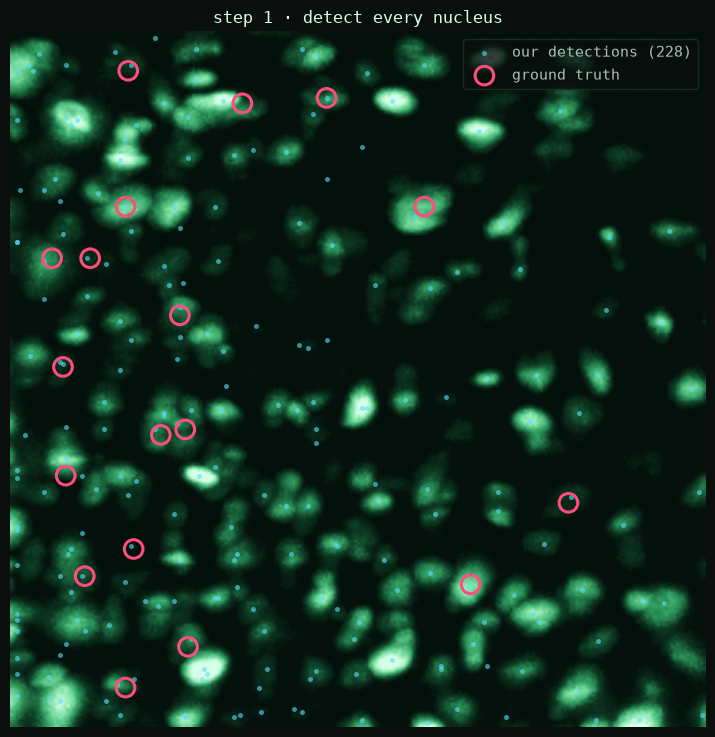

In [6]:
cfg = PipelineConfig(xy_ds=2, thresh_rel=0.30, link_method="ilp")
coords,_ = detect_cells(vs.volume(0), cfg)                 # detection on frame 0
fig,ax=plt.subplots(figsize=(7.5,7.5))
ax.imshow(proj(0),cmap=NG,interpolation="bilinear")
ax.scatter(coords[:,2],coords[:,1],s=13,c=CYAN,alpha=0.6,linewidths=0,label=f"our detections ({len(coords)})")
if gt0: ax.scatter(*zip(*gt0),s=180,facecolors="none",edgecolors=MAG,linewidths=2.2,label="ground truth")
ax.set_axis_off(); ax.legend(loc="upper right",facecolor=BG,edgecolor="#22302a",labelcolor=INK)
ax.set_title("step 1 · detect every nucleus",color="#d6ffe8",fontsize=12); plt.tight_layout(); plt.show()

## 6 · Where it stands

Our local reconstruction score, step by step, on a held-out 13-clip validation set — **greedy baseline → global
ILP linking → finer detection → tuned config** — a **+0.11** climb, entirely classical and fully offline.

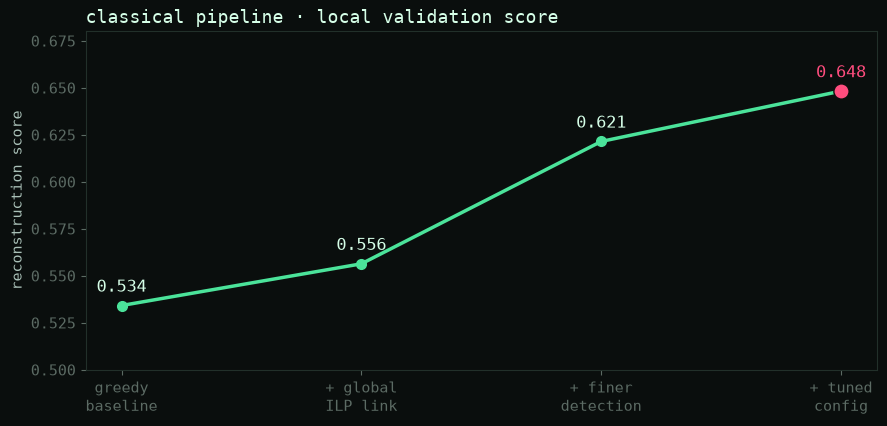

Public leaderboard tops out ~0.91 (median ~0.83). The remaining gap is a detection problem:
on the densest clips, the hardest cells still slip outside the 7µm cliff — the next lever is a learned 3D detector.


In [7]:
labels=["greedy\nbaseline","+ global\nILP link","+ finer\ndetection","+ tuned\nconfig"]
scores=[0.5341,0.5563,0.6214,0.6482]
fig,ax=plt.subplots(figsize=(9,4.4))
ax.plot(range(4),scores,color=GREEN,lw=2.5,marker="o",ms=7)
ax.scatter([3],[scores[-1]],s=120,c=MAG,edgecolors=BG,zorder=3)
for i,s in enumerate(scores):
    ax.annotate(f"{s:.3f}",(i,s),(0,10),textcoords="offset points",ha="center",
                color=MAG if i==3 else "#d6ffe8",fontsize=12)
ax.set_xticks(range(4)); ax.set_xticklabels(labels); ax.set_ylabel("reconstruction score")
ax.set_ylim(0.50,0.68); ax.set_title("classical pipeline · local validation score",color="#d6ffe8",loc="left")
plt.tight_layout(); plt.show()
print("Public leaderboard tops out ~0.91 (median ~0.83). The remaining gap is a detection problem:")
print("on the densest clips, the hardest cells still slip outside the 7µm cliff — the next lever is a learned 3D detector.")

---
*Data: zebrafish embryo light-sheet microscopy (Royer Lab / CZ Biohub, Zebrahub). All figures regenerated from
training clip `6bba_09961292` and the `pipeline/` package — detection, linking, and validation are our own.*